<a href="https://colab.research.google.com/github/Jasmine25005/Guide-to-Sentiment-Classification-with-NLP-Comparing-DNN-RNN-and-LSTM/blob/main/Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:#0b7a98; border-radius:12px; padding:18px 24px; margin-bottom:18px; border:3px solid #000; box-shadow:0 6px 18px rgba(0,0,0,0.12);">
  <h1 style="color:#fff; font-family:Georgia, 'Times New Roman', serif; text-align:center; margin:0; font-size:34px;">
    A Practical Guide to Sentiment Classification with NLP: Comparing DNN, RNN, and LSTM
  </h1>
  <p style="color:#f6ffd5; text-align:center; margin:6px 0 0; font-weight:600;">
    An end-to-end walkthrough of a real-world sentiment analysis project, from raw text to a final, predictive model.
  </p>
</div>

---

### Complete NLP Blueprint
This notebook is a **complete, step-by-step guide** to a standard NLP project. builing a functional sentiment classifier, covering every essential stage. You'll get to see not just the "how," but also the "why."

1.  **Data Loading & EDA:** I begin by importing raw Twitter data and performing effective Exploratory Data Analysis (EDA) with visualizations like word clouds and label distributions to truly understand our dataset.

2.  **Advanced Preprocessing:** You'll see two professional-grade text cleaning pipelines in action:
    * **For the DNN:** Using `spaCy` for deep cleaning, including lemmatization and stop-word removal.
    * **For RNN/LSTM:** Using the Keras `Tokenizer` to convert text into sequences suitable for recurrent networks.

3.  **Vectorization Strategies:** I'll implement and compare two classic vectorization techniques:
    * **TF-IDF:** A statistical method to represent word importance.
    * **Embeddings:** A deep learning approach to capture word meaning and context.

4.  **Model Building & Training:** I will construct and train three different neural network architectures from scratch to see which performs best on our text data.

5.  **Head-to-Head Evaluation:** After training. I'll use **classification reports** and **confusion matrices** to rigorously evaluate all three models.

6.  **Live Demo:** The best part! using the winning model to make predictions on brand-new, unseen sentences, completing the project lifecycle and you can **try it yourself** too, it's found in the last section of the notebook.

---

I hope you find this end-to-end guide helpful on your learning journey. If you do, an **upvote👍** would be greatly appreciated.

# Installing required libraries

In [ ]:
#!pip install spacy
#!python -m spacy download en_core_web_sm

In [ ]:
import kagglehub
jp797498e_twitter_entity_sentiment_analysis_path = kagglehub.dataset_download('jp797498e/twitter-entity-sentiment-analysis')

print('Data source import complete.')

Data source import complete.


Since there is no a dedicated test file, a val one instead so i am gonna use it as the test data

# Data Loading

In [ ]:
import os
import pandas as pd

cols = ['id', 'src', 'label', 'tweet']
Datatra = pd.read_csv(os.path.join(jp797498e_twitter_entity_sentiment_analysis_path, 'twitter_training.csv'), names=cols)
Datatest = pd.read_csv(os.path.join(jp797498e_twitter_entity_sentiment_analysis_path, 'twitter_validation.csv'), names=cols)

Datatra.head()

,id,src,label,tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


# EDA

In [ ]:
Datatest.head()

,id,src,label,tweet
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


In [ ]:
Datatra.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      74682 non-null  int64 
 1   src     74682 non-null  object
 2   label   74682 non-null  object
 3   tweet   73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [ ]:
print(f'Train nulls:\n{Datatra.isna().sum()}')

print(f'Test nulls:\n{Datatest.isna().sum()}')

train nulls:
id         0
src        0
label      0
tweet    686
dtype: int64
Test nulls:
id       0
src      0
label    0
tweet    0
dtype: int64


In [ ]:
Datatra = Datatra.dropna(subset=['tweet'])

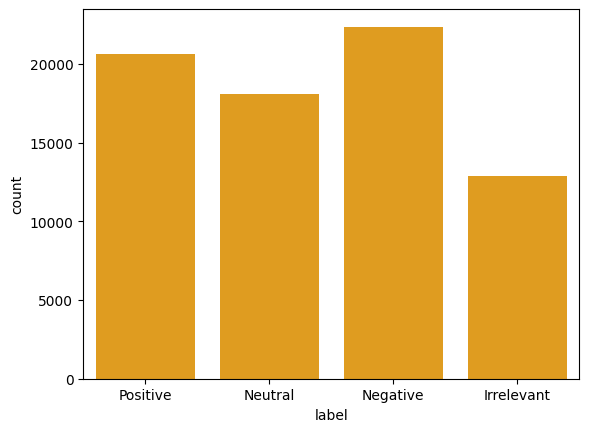

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='label', data=Datatra, color='orange')
plt.show()

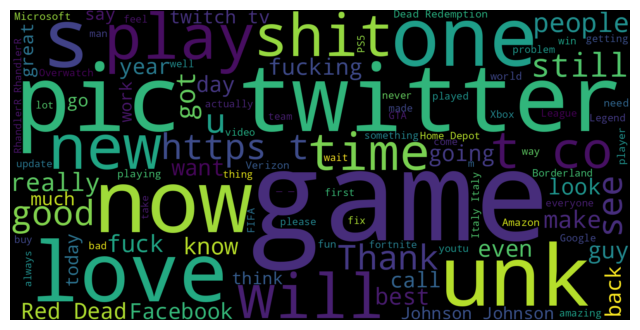

In [ ]:
from wordcloud import WordCloud
plt.figure(figsize=(8, 6))
wc = WordCloud(max_words=100, width=1600, height=800).generate(" ".join(Datatra['tweet']))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')  # Hide axes for better visualization
plt.show()

# NLP Pipeline

# 1. Preprocessing

## a) Preprocessing with spaCy (for the DNN Model)

This pipeline uses `spaCy` for advanced text cleaning, including:
* Lemmatization (reducing words to their root form).
* Removal of stop words and punctuation.

In [ ]:
import spacy as spc
tokenizer = spc.load('en_core_web_sm')

def preprocessing_pipe(texts):
    docs = tokenizer.pipe(
        texts,
        n_process=4,  # No of CPUs
        batch_size=64,
    )
    for doc in docs:
        yield " ".join([token.lemma_ for token in doc if not token.is_stop and not token.is_punct])

## b) Preprocessing with Keras Tokenizer (for RNN/LSTM Models)

This approach uses TensorFlow's `Tokenizer` to convert raw text directly into integer sequences. An `oov_token` is included to handle words that appear in the test set but not in the training vocabulary.

In [ ]:
from tqdm import tqdm
# Applying preprocessing to each tweet in the Series
tqdm.pandas()
Datatra['cleanedtweet'] = list(preprocessing_pipe(Datatra['tweet']))
Datatest['cleanedtweet'] = list(preprocessing_pipe(Datatest['tweet']))

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizerr = Tokenizer(oov_token="<OOV>")

tokenizerr.fit_on_texts(Datatra['cleanedtweet'])

sequences = tokenizerr.texts_to_sequences(Datatra['cleanedtweet'])
maxseq_len = max(len(seq) for seq in sequences)
wordscount = len(tokenizerr.word_index) + 1

2025-09-20 18:44:57.999517: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758393898.203750      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758393898.263496      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# 2. Vectorization with TF-IDF

This function creates TF-IDF vectors from the cleaned text. It will only be used for the DNN model. The RNN/LSTM models will use an `Embedding` layer for vectorization, which is built directly into the model architecture.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
def vectorization(tratxt, valtxt=None):
    vect = TfidfVectorizer()
    x_train = vect.fit_transform(tratxt)
    if valtxt is not None:
        x_val = vect.transform(valtxt)
        return x_train, x_val, vect
    return x_train, vect

# 3. Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
Datatra['label'] = le.fit_transform(Datatra['label'])
Datatest['label'] = le.transform(Datatest['label'])

In [ ]:
print(Datatra.shape)
print(Datatest.shape)

(73996, 5)
(1000, 5)


# DNN Model

In [ ]:
from tqdm import tqdm
from sklearn.model_selection import train_test_split

x, vect = vectorization(Datatra['cleanedtweet'])
y = Datatra['label']

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# Applying preprocessing to each tweet in the Series
x_test = vect.transform(Datatest['cleanedtweet'])
y_test = Datatest['label']

In [ ]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

model = Sequential(
    [
        Dense(64, activation='relu', input_dim=x_train.shape[1]),
        Dense(32, activation='relu'),
        Dense(y_train.nunique(), activation='softmax')
    ]
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1758393911.222346      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1758393911.223167      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model.fit(x_train, y_train, epochs=10, validation_data=(x_val, y_val))

Epoch 1/10


I0000 00:00:1758393914.395991     119 service.cc:148] XLA service 0x7dd544012710 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758393914.396482     119 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1758393914.396506     119 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1758393914.590319     119 cuda_dnn.cc:529] Loaded cuDNN version 90300


   1/1850 ━━━━━━━━━━━━━━━━━━━━ 1:14:45 2s/step - accuracy: 0.1562 - loss: 1.3880

I0000 00:00:1758393915.550739     119 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1850/1850 ━━━━━━━━━━━━━━━━━━━━ 135s 72ms/step - accuracy: 0.6017 - loss: 0.9598 - val_accuracy: 0.8404 - val_loss: 0.4383
Epoch 2/10
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8898 - loss: 0.2987 - val_accuracy: 0.8734 - val_loss: 0.3489
Epoch 3/10
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9308 - loss: 0.1837 - val_accuracy: 0.8853 - val_loss: 0.3314
Epoch 4/10
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9508 - loss: 0.1268 - val_accuracy: 0.8920 - val_loss: 0.3365
Epoch 5/10
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9588 - loss: 0.0992 - val_accuracy: 0.8964 - val_loss: 0.3366
Epoch 6/10
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9635 - loss: 0.0868 - val_accuracy: 0.8972 - val_loss: 0.3489
Epoch 7/10
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9656 - loss: 0.0796 - val_accuracy: 0.8976 - val_loss: 0.3690
Epoch 8/10
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9661 - loss: 0.0762 - val_ac

In [ ]:
model.evaluate(x_test, y_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.9658 - loss: 0.1767


[0.16177386045455933, 0.9739999771118164]

In [ ]:
model.save('model.h5')

## DNN Model Evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_preds = model.predict(x_test)
y_pred_classes = np.argmax(y_preds, axis=1) # Convert probabilities to class labels
print(classification_report(y_test, y_pred_classes))

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       172
           1       0.97      0.97      0.97       266
           2       0.98      0.98      0.98       285
           3       0.97      0.97      0.97       277

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



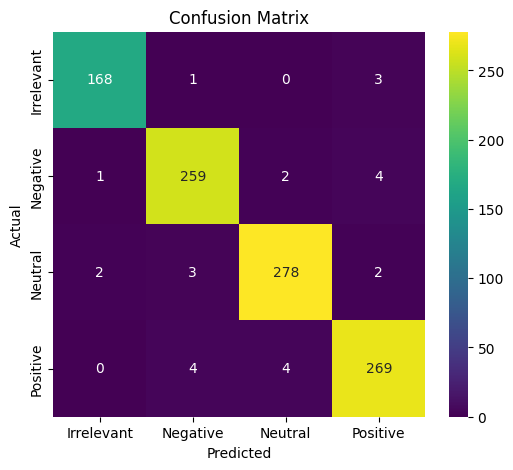

In [ ]:
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='viridis',
            xticklabels=le.classes_,  # Use the encoder's stored class names
            yticklabels=le.classes_)  # Use the encoder's stored class names

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Recurrent Neural Network Models (SimpleRNN & LSTM)

## Data Preparation for Sequence Models

In [ ]:
from sklearn.model_selection import train_test_split

# training data preparation
xr = pad_sequences(sequences, maxlen=maxseq_len)
yr = Datatra['label']
xr_train, xr_val, yr_train, yr_val = train_test_split(xr, yr, test_size=0.2, random_state=42, stratify=yr)
# testing data preparation
xr_test = pad_sequences(tokenizerr.texts_to_sequences(Datatest['cleanedtweet']), maxlen=maxseq_len)
yr_test = Datatest['label']

## 1. SimpleRNN

In [ ]:
from tensorflow.keras.layers import Embedding, Dense, SimpleRNN
from tensorflow.keras.models import Sequential

modelr = Sequential([
    Embedding(input_dim=wordscount, output_dim=200, input_length=maxseq_len), # Vectorizer
    SimpleRNN(256),
    Dense(yr_train.nunique(), activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
from tensorflow.keras.optimizers import Adam

modelr.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [ ]:
modelr.fit(xr_train, yr_train, epochs=20, validation_data=(xr_val, yr_val), callbacks=[early_stopping])

Epoch 1/20
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 37s 18ms/step - accuracy: 0.7468 - loss: 0.6421 - val_accuracy: 0.6894 - val_loss: 0.7988
Epoch 2/20
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.7625 - loss: 0.6015 - val_accuracy: 0.7075 - val_loss: 0.7770
Epoch 3/20
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.7760 - loss: 0.5750 - val_accuracy: 0.7152 - val_loss: 0.7681
Epoch 4/20
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.7900 - loss: 0.5435 - val_accuracy: 0.7202 - val_loss: 0.7627
Epoch 5/20
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.7991 - loss: 0.5205 - val_accuracy: 0.7266 - val_loss: 0.7632
Epoch 6/20
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.8111 - loss: 0.4921 - val_accuracy: 0.7335 - val_loss: 0.7588
Epoch 7/20
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.8174 - loss: 0.4724 - val_accuracy: 0.7341 - val_loss: 0.7574
Epoch 8/20
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.8253 -

### SimpleRNN model Evaluation

In [ ]:
modelr.evaluate(xr_test, yr_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7400 - loss: 0.8166


[0.76796954870224, 0.75]

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_predsr = modelr.predict(xr_test)
y_pred_classesr = np.argmax(y_predsr, axis=1) # Convert probabilities to class labels
print(classification_report(yr_test, y_pred_classesr))

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
              precision    recall  f1-score   support

           0       0.67      0.70      0.69       172
           1       0.80      0.79      0.80       266
           2       0.85      0.69      0.76       285
           3       0.68      0.80      0.74       277

    accuracy                           0.75      1000
   macro avg       0.75      0.75      0.75      1000
weighted avg       0.76      0.75      0.75      1000



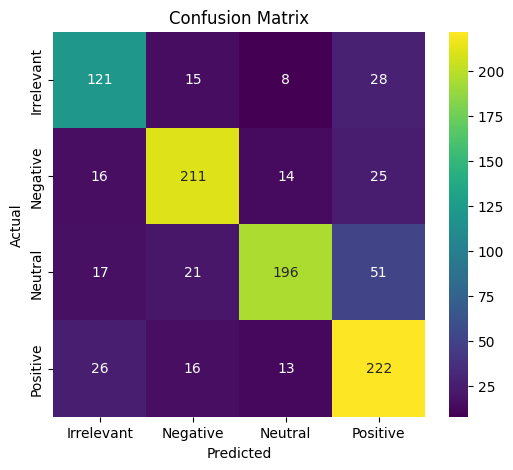

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from matplotlib import pyplot as plt
import seaborn as sns

cmr = confusion_matrix(yr_test, y_pred_classesr)
plt.figure(figsize=(6, 5))
sns.heatmap(cmr,
            annot=True,
            fmt='d',
            cmap='viridis',
            xticklabels=le.classes_,  # Use the encoder's stored class names
            yticklabels=le.classes_)  # Use the encoder's stored class names

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 2. LSTM Model

In [ ]:
from tensorflow.keras.layers import LSTM

modelstm = Sequential([
    Embedding(input_dim=wordscount, output_dim=200, input_length=maxseq_len),
    LSTM(256),
    Dense(yr_train.nunique(), activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
modelstm.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
modelstm.fit(xr_train, yr_train, epochs=20, validation_data=(xr_val, yr_val), callbacks=[early_stopping])

Epoch 1/20
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - accuracy: 0.9423 - loss: 0.1515 - val_accuracy: 0.8653 - val_loss: 0.4379
Epoch 2/20
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9530 - loss: 0.1198 - val_accuracy: 0.8699 - val_loss: 0.4479
Epoch 3/20
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9598 - loss: 0.1034 - val_accuracy: 0.8733 - val_loss: 0.4589
Epoch 4/20
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9617 - loss: 0.0926 - val_accuracy: 0.8738 - val_loss: 0.4715
Epoch 5/20
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9663 - loss: 0.0827 - val_accuracy: 0.8718 - val_loss: 0.4819
Epoch 6/20
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9674 - loss: 0.0760 - val_accuracy: 0.8713 - val_loss: 0.5016
Epoch 7/20
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9684 - loss: 0.0735 - val_accuracy: 0.8742 - val_loss: 0.5097
Epoch 8/20
   5/1850 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9494 -

In [ ]:
modelstm.save('modelstm.h5')

### LSTM model Evaluation

In [ ]:
modelstm.evaluate(xr_test, yr_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9188 - loss: 0.3651


[0.342562735080719, 0.9200000166893005]

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_predstm = modelstm.predict(xr_test)
y_pred_classestm = np.argmax(y_predstm, axis=1) # Convert probabilities to class labels
print(classification_report(yr_test, y_pred_classestm))

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
              precision    recall  f1-score   support

           0       0.89      0.96      0.92       172
           1       0.92      0.94      0.93       266
           2       0.94      0.89      0.92       285
           3       0.92      0.90      0.91       277

    accuracy                           0.92      1000
   macro avg       0.92      0.92      0.92      1000
weighted avg       0.92      0.92      0.92      1000



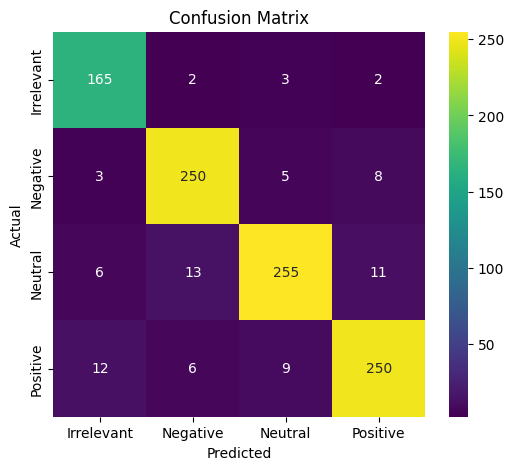

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from matplotlib import pyplot as plt
import seaborn as sns

cmtm = confusion_matrix(yr_test, y_pred_classestm)
plt.figure(figsize=(6, 5))
sns.heatmap(cmtm,
            annot=True,
            fmt='d',
            cmap='viridis',
            xticklabels=le.classes_,  # Use the encoder's stored class names
            yticklabels=le.classes_)  # Use the encoder's stored class names

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## Model Comparison and Final Test with unseen data on the winning model(DNN)
Based on each evaluation result for each of the three models, The DNN Model is the best!!!

In [ ]:
TestingTxt = [
    'My Friend Pedro is the best',
    'Some people are getting me on my nerves!!, I hate them',
    'Hornet is stronger than Hollowknight!',
    'Assassains Creed Syndicate is the worst in the series.',
    'it\'s okay to be yourself'
]

# Passing the list of strings directly to the preprocessing function
pre_txt = preprocessing_pipe(TestingTxt)

# Transforming the cleaned text into TF-IDF vectors
vect_txt = vect.transform(pre_txt)

# Get the model's predictions
pred = model.predict(vect_txt)

# Get the final class labels
predicted_classes = np.argmax(pred, axis=1)
final_labels = le.inverse_transform(predicted_classes)

print(final_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
['Positive' 'Negative' 'Positive' 'Negative' 'Neutral']
